# 06 — ต่อยอดด้วยข้อมูลจริง: BPI Challenge 2019

ใช้คำถามชุดเดียวกับ notebook 01–05 กับ event log **จริง** ของบริษัทข้ามชาติด้านสีและสารเคลือบ (ข้อมูลถูกทำให้นิรนาม)
แล้วเปรียบเทียบผลกับข้อมูลจำลอง เพื่อดูว่าวิธีการใช้ได้กับข้อมูลจริงที่ซับซ้อนกว่าหรือไม่

**ข้อมูล:** BPI Challenge 2019, DOI 10.4121/uuid:d06aff4b-79f0-45e6-8ec8-e19730c248f1, CC BY 4.0
ดาวน์โหลดจาก [figshare](https://figshare.com/articles/dataset/BPI_Challenge_2019/12715853) (ระบบเดิมของ 4TU.ResearchData)
ไฟล์ `BPI_Challenge_2019.xes` (MD5 `4eb909242351193a61e1c15b9c3cc814`) วางไว้ใน `data/` ไฟล์ใหญ่ ~700 MB จึงไม่อยู่ใน repo

**ความแตกต่างของโครงสร้าง:** ชุดนี้เป็น XES แบบดั้งเดิม 1 เคส = รายการสินค้า 1 บรรทัดในใบสั่งซื้อ (purchase order item)
ไม่ใช่ object-centric แบบชุดจำลอง และแบ่งเป็น 4 ประเภทการจับคู่เอกสาร (item category) ซึ่งมีกติกาต่างกัน

In [1]:
import os; os.environ['PM4PY_SHOW_PROGRESS_BAR'] = 'False'
import sys, json, hashlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import bpi2019 as b, p2p_viz as viz
ROOT = Path.cwd().parent; FIG = ROOT/'figures'; R = {}
src = b.find_xes(); R['source_file'] = src.name
ev, cs = b.load()
ev = ev.sort_values(['case', 'timestamp', 'position']).reset_index(drop=True)
R['events'] = len(ev); R['cases'] = int(cs['case'].nunique()); R['activities'] = int(ev.activity.nunique())
R['purchase_documents'] = int(cs['document'].nunique()); R['vendors'] = int(cs['vendor'].nunique())
R['companies'] = int(cs['company'].nunique())
R['users'] = int(ev['user'].nunique()); R['batch_user_event_pct'] = round(100*ev['user'].str.startswith('batch').mean(), 1)
{k: R[k] for k in ['events','cases','activities','purchase_documents','vendors','companies','users','batch_user_event_pct']}

{'events': 1595923,
 'cases': 251734,
 'activities': 42,
 'purchase_documents': 76349,
 'vendors': 1975,
 'companies': 4,
 'users': 628,
 'batch_user_event_pct': np.float64(9.8)}

ตัวเลขข้างบนตรงกับที่ผู้จัดทำประกาศไว้ (251,734 เคส, 1,595,923 events, 42 activities) จึงมั่นใจได้ว่าอ่านไฟล์ครบ

## 1. คุณภาพข้อมูล

In [2]:
R['time_min'] = str(ev.timestamp.min()); R['time_max'] = str(ev.timestamp.max())
yr = ev.timestamp.dt.year
R['events_per_year'] = {int(k): int(v) for k, v in yr.value_counts().sort_index().items()}
odd = ev[ev.timestamp < '2018-01-01'].case.unique()
R['events_before_2018'] = int((ev.timestamp < '2018-01-01').sum())
R['cases_with_events_before_2018'] = int(len(odd))
R['null_values'] = int(ev.isna().sum().sum())
R['events_per_year']

{1948: 10,
 1993: 9,
 2001: 22,
 2008: 45,
 2015: 3,
 2016: 6,
 2017: 223,
 2018: 1550468,
 2019: 45135,
 2020: 2}

ข้อมูลส่วนใหญ่อยู่ในปี 2018 แต่มี event ย้อนไปถึงปี 1948 ซึ่งเป็นไปไม่ได้ทางธุรกิจ จึงตัดเคสที่มี event ก่อนปี 2018 ออกจากการวิเคราะห์ด้านเวลา
(ตัดเฉพาะการวัดเวลา ส่วนการตรวจลำดับยังใช้ทุกเคส)

In [3]:
cat = cs.set_index('case')['item_category']
R['item_category_cases'] = cat.value_counts().to_dict()
R['item_category_pct'] = (100*cat.value_counts(normalize=True)).round(1).to_dict()
pd.DataFrame({'cases': cat.value_counts(), '%': (100*cat.value_counts(normalize=True)).round(1)})

,cases,%
item_category,,
"3-way match, invoice before GR",221010,87.8
"3-way match, invoice after GR",15182,6.0
Consignment,14498,5.8
2-way match,1044,0.4


ความหมายของ 4 ประเภท (จากคำอธิบายของชุดข้อมูล)
- **3-way match, invoice before GR:** ต้องมีใบรับของ ใบแจ้งหนี้มาก่อนรับของได้ แต่ต้องถูกบล็อกไว้จนกว่าจะรับของ
- **3-way match, invoice after GR:** ต้องรับของก่อน แล้วจึงบันทึกใบแจ้งหนี้ (GR-based invoice verification)
- **2-way match:** ไม่ต้องมีใบรับของ จับคู่ใบแจ้งหนี้กับ PO
- **Consignment:** ของฝากขาย ไม่มีใบแจ้งหนี้ในระดับ PO

## 2. กระบวนการที่เกิดขึ้นจริง

{'variants': 11973,
 'variants_singletons': 9030,
 'top1_coverage_pct': np.float64(20.0),
 'top10_coverage_pct': np.float64(59.5),
 'variants_needed_for_50pct': 7,
 'variants_needed_for_80pct': 45}

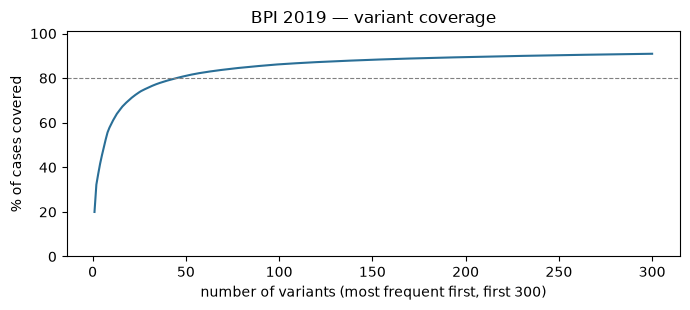

In [4]:
trace = ev.groupby('case').activity.agg(tuple)
vc = trace.value_counts(); cum = vc.cumsum()/vc.sum()*100
R['variants'] = len(vc); R['variants_singletons'] = int((vc==1).sum())
R['top1_coverage_pct'] = round(cum.iloc[0],1); R['top10_coverage_pct'] = round(cum.iloc[9],1)
R['variants_needed_for_50pct'] = int((cum<50).sum()+1); R['variants_needed_for_80pct'] = int((cum<80).sum()+1)
R['top_variants'] = [{'variant': ' > '.join(k), 'cases': int(v), 'pct': round(100*v/len(trace),1)} for k, v in vc.head(5).items()]
fig, ax = plt.subplots(figsize=(7,3.2))
ax.plot(range(1, min(len(cum), 300)+1), cum.values[:300], color='#2a6f97')
ax.axhline(80, ls='--', color='grey', lw=.8); ax.set_ylim(0,101)
ax.set_xlabel('number of variants (most frequent first, first 300)'); ax.set_ylabel('% of cases covered')
ax.set_title('BPI 2019 — variant coverage'); fig.tight_layout(); fig.savefig(FIG/'06_variant_coverage.png', dpi=150)
{k:R[k] for k in ['variants','variants_singletons','top1_coverage_pct','top10_coverage_pct','variants_needed_for_50pct','variants_needed_for_80pct']}

In [5]:
pd.DataFrame(R['top_variants'])

,variant,cases,pct
0,Create Purchase Order Item > Vendor creates in...,50286,20.0
1,Create Purchase Order Item > Record Goods Rece...,30798,12.2
2,Create Purchase Order Item > Record Goods Receipt,12214,4.9
3,Create Purchase Order Item > Vendor creates in...,11383,4.5
4,Create Purchase Order Item > Receive Order Con...,9694,3.9


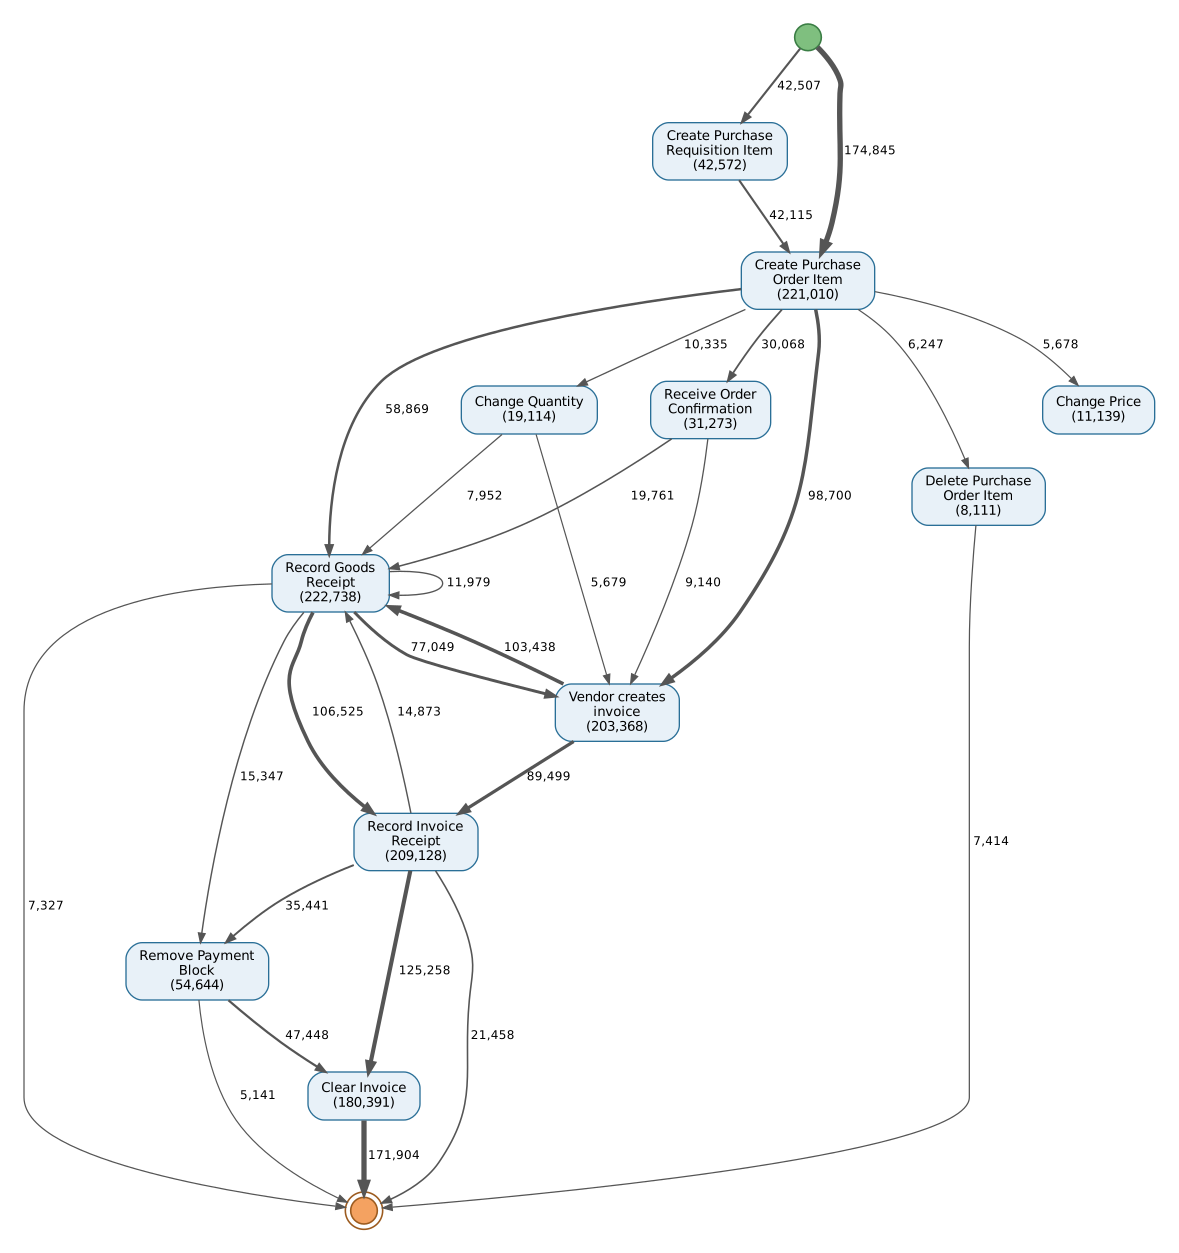

In [6]:
# Directly-follows graph ของประเภทหลัก (3-way, invoice before GR) แสดงเฉพาะเส้นที่เกิดในอย่างน้อย 2% ของเคส
main = '3-way match, invoice before GR'
m = ev[ev.case.map(cat) == main]
nxt = m.groupby('case').activity.shift(-1)
pairs = pd.DataFrame({'a': m.activity, 'b': nxt}).dropna().value_counts()
n_main = m.case.nunique(); thr = 0.02*n_main
dfg = {k: int(v) for k, v in pairs.items() if v >= thr}
starts = m.groupby('case').activity.first().value_counts(); ends = m.groupby('case').activity.last().value_counts()
keep = {a for e in dfg for a in e}
sa = {k: int(v) for k, v in starts.items() if k in keep and v >= thr}
ea = {k: int(v) for k, v in ends.items() if k in keep and v >= thr}
counts = m.activity.value_counts(); counts = {k: int(v) for k, v in counts.items() if k in keep}
viz.dfg_graph(dfg, sa, ea, counts, rankdir='TB').render(str(FIG/'06_dfg_main'), format='png', cleanup=True)
R['dfg_main_threshold_pct'] = 2; R['dfg_main_edges_shown'] = len(dfg); R['dfg_main_edges_total'] = int(len(pairs))
from IPython.display import Image; Image(str(FIG/'06_dfg_main.png'), width=700)

## 3. ความสอดคล้องกับกติกา (ตรวจแยกตามประเภท)
ใช้กติกาจากคำอธิบายของชุดข้อมูลเอง ไม่ได้ตั้งขึ้นใหม่

In [7]:
first = ev.groupby(['case','activity']).timestamp.min().unstack()
count = ev.groupby(['case','activity']).size().unstack(fill_value=0)
gr, inv, clr = first['Record Goods Receipt'], first['Record Invoice Receipt'], first['Clear Invoice']
ccat = cat.reindex(first.index)
def share(mask, cats):
    sel = ccat.isin(cats)
    return int(mask[sel].sum()), round(100*mask[sel].mean(), 2), int(sel.sum())
rules = {
  'R1 invoice recorded before goods receipt (invoice after GR required)':
      share((inv < gr) | (inv.notna() & gr.isna()), ['3-way match, invoice after GR']),
  'R2 invoice cleared (paid) before any goods receipt (3-way match)':
      share((clr < gr) | (clr.notna() & gr.isna()), ['3-way match, invoice before GR','3-way match, invoice after GR']),
  'R3 goods receipt recorded for 2-way match item':
      share(gr.notna(), ['2-way match']),
  'R4 invoice recorded for consignment item':
      share(inv.notna(), ['Consignment']),
}
rt = pd.DataFrame(rules, index=['cases','% of category','category cases']).T
R['rules'] = [{'rule': k, 'cases': int(v[0]), 'pct_of_category': v[1], 'category_cases': int(v[2])} for k, v in rules.items()]
rt

,cases,% of category,category cases
R1 invoice recorded before goods receipt (invoice after GR required),0.0,0.00,15182.0
R2 invoice cleared (paid) before any goods receipt (3-way match),655.0,0.28,236192.0
R3 goods receipt recorded for 2-way match item,0.0,0.00,1044.0
R4 invoice recorded for consignment item,0.0,0.00,14498.0


In [8]:
# ใบแจ้งหนี้มาก่อนรับของในประเภท invoice-before-GR: ทำได้ แต่ต้องถูกบล็อกจนกว่าจะรับของ
ib = ccat == '3-way match, invoice before GR'
early_inv = ib & (inv < gr)
R['ibgr_invoice_before_gr_cases'] = int(early_inv.sum()); R['ibgr_invoice_before_gr_pct'] = round(100*early_inv[ib].mean(), 1)
R['ibgr_paid_without_any_gr_cases'] = int((ib & clr.notna() & gr.isna()).sum())
R['remove_payment_block_cases_pct'] = round(100*count['Remove Payment Block'].gt(0).mean(), 1)
{k:R[k] for k in ['ibgr_invoice_before_gr_cases','ibgr_invoice_before_gr_pct','ibgr_paid_without_any_gr_cases','remove_payment_block_cases_pct']}

{'ibgr_invoice_before_gr_cases': 16356,
 'ibgr_invoice_before_gr_pct': np.float64(7.4),
 'ibgr_paid_without_any_gr_cases': 565,
 'remove_payment_block_cases_pct': np.float64(22.2)}

In [9]:
# สถานะเคส: log เป็นภาพ ณ วันที่ดึงข้อมูล เคสที่ต้องมีใบแจ้งหนี้แต่ยังไม่ถูกจ่ายถือว่ายังเปิดอยู่
needs_pay = ccat.isin(['3-way match, invoice before GR','3-way match, invoice after GR','2-way match'])
R['open_cases_pct_of_invoiced_categories'] = round(100*clr[needs_pay].isna().mean(), 1)
R['cases_with_purchase_requisition_pct'] = round(100*first['Create Purchase Requisition Item'].notna().mean(), 1)
{k:R[k] for k in ['open_cases_pct_of_invoiced_categories','cases_with_purchase_requisition_pct']}

{'open_cases_pct_of_invoiced_categories': np.float64(22.6),
 'cases_with_purchase_requisition_pct': np.float64(18.5)}

**อ่านผล:** ในข้อมูลจริง การจ่ายเงินก่อนรับของแทบไม่เกิดขึ้น และประเภท 2-way / consignment ทำตามกติกา
แต่ใบแจ้งหนี้ที่มาก่อนรับของมีจำนวนมาก ทำให้ต้อง**ปลดบล็อกการจ่ายเงิน**ด้วยมือหรือ batch บ่อย ซึ่งเป็นงานเพิ่มและเวลารอ
ใบขอซื้อในระบบมีเพียงส่วนน้อยของเคส แต่ข้อมูลชุดนี้ไม่ได้ระบุว่าทุกการซื้อต้องมีใบขอซื้อ จึง**ไม่นับเป็นการผิดกฎ** (ต่างจากชุดจำลอง)

## 4. การทำงานซ้ำและการแก้ไขเอกสาร

In [10]:
rework_acts = ['Change Quantity','Change Price','Delete Purchase Order Item','Cancel Invoice Receipt',
               'Cancel Goods Receipt','Change Approval for Purchase Order','Remove Payment Block']
rw = pd.DataFrame({'cases': [int(count[a].gt(0).sum()) for a in rework_acts],
                   'pct_cases': [round(100*count[a].gt(0).mean(), 2) for a in rework_acts]}, index=rework_acts)
R['rework'] = rw.reset_index(names='activity').to_dict('records')
any_change = count[[a for a in rework_acts if a != 'Remove Payment Block']].gt(0).any(axis=1)
R['cases_with_any_change_or_cancel_pct'] = round(100*any_change.mean(), 1)
rw

,cases,pct_cases
Change Quantity,17590,6.99
Change Price,11224,4.46
Delete Purchase Order Item,8839,3.51
Cancel Invoice Receipt,6471,2.57
Cancel Goods Receipt,2470,0.98
Change Approval for Purchase Order,4377,1.74
Remove Payment Block,55839,22.18


## 5. ระยะเวลา (ไม่รวมเคสที่มี timestamp ผิดปกติ)

In [11]:
clean = ~first.index.isin(odd)
po = first['Create Purchase Order Item']
DAY = 86400
def stat(s):
    s = s[clean].dropna(); s = s[s >= 0]
    return {'n': int(s.size), 'median': round(s.median(),1), 'mean': round(s.mean(),1), 'p90': round(s.quantile(.9),1)}
d = lambda a, b_: (b_ - a).dt.total_seconds()/DAY
stages = {
  'PO item created -> first goods receipt': stat(d(po, gr)),
  'first goods receipt -> invoice recorded': stat(d(gr, inv).where(inv >= gr)),
  'invoice recorded -> invoice cleared': stat(d(inv, clr)),
  'PO item created -> invoice cleared (end to end)': stat(d(po, clr)),
}
R['stage_days'] = stages
pd.DataFrame(stages).T

,n,median,mean,p90
PO item created -> first goods receipt,234232.0,10.0,15.5,34.1
first goods receipt -> invoice recorded,193785.0,11.3,20.6,48.0
invoice recorded -> invoice cleared,183013.0,42.1,48.2,97.1
PO item created -> invoice cleared (end to end),183419.0,77.0,80.0,126.2


{'invoice_to_clear_median_with_block_removal': np.float64(51.2),
 'invoice_to_clear_median_without_block_removal': np.float64(37.3)}

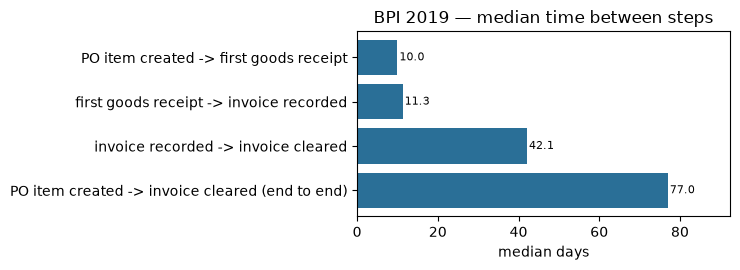

In [12]:
# เคสที่ต้องปลดบล็อกการจ่าย ใช้เวลาจากใบแจ้งหนี้ถึงจ่ายนานกว่าหรือไม่
blocked = count['Remove Payment Block'].gt(0)
w = d(inv, clr)[clean]
R['invoice_to_clear_median_with_block_removal'] = round(w[blocked[clean]].median(), 1)
R['invoice_to_clear_median_without_block_removal'] = round(w[~blocked[clean]].median(), 1)
by_cat = {k: stat(d(po, clr).where(ccat == k)) for k in ['3-way match, invoice before GR','3-way match, invoice after GR','2-way match']}
R['end_to_end_by_category'] = by_cat
plot = pd.Series({k: v['median'] for k, v in stages.items()}).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5,2.8)); ax.barh(plot.index, plot.values, color='#2a6f97')
for y, v in enumerate(plot.values): ax.text(v+0.5, y, f'{v:.1f}', va='center', fontsize=8)
ax.set_xlabel('median days'); ax.set_title('BPI 2019 — median time between steps'); ax.set_xlim(0, plot.max()*1.2)
fig.tight_layout(); fig.savefig(FIG/'06_stage_days.png', dpi=150)
{k:R[k] for k in ['invoice_to_clear_median_with_block_removal','invoice_to_clear_median_without_block_removal']}

## 6. เทียบกับข้อมูลจำลอง

In [13]:
C = json.loads((ROOT/'results'/'03_conformance.json').read_text())
P = json.loads((ROOT/'results'/'04_performance.json').read_text())
D = json.loads((ROOT/'results'/'02_discovery.json').read_text())
cmp = pd.DataFrame([
  {'metric': 'Cases', 'simulated (Zenodo P2P)': f"{C['cases']:,} (1 case = 1 PR)", 'real (BPI 2019)': f"{R['cases']:,} (1 case = 1 PO item)"},
  {'metric': 'Events', 'simulated (Zenodo P2P)': f"{D['events']:,}", 'real (BPI 2019)': f"{R['events']:,}"},
  {'metric': 'Variants', 'simulated (Zenodo P2P)': f"{D['variants_full']:,}", 'real (BPI 2019)': f"{R['variants']:,}"},
  {'metric': 'Variants for 80% of cases', 'simulated (Zenodo P2P)': D['variants_needed_for_80pct'], 'real (BPI 2019)': R['variants_needed_for_80pct']},
  {'metric': 'Paid before any goods receipt', 'simulated (Zenodo P2P)': '0%', 'real (BPI 2019)': f"{R['rules'][1]['pct_of_category']}% of 3-way items"},
  {'metric': 'Cases still open (not paid)', 'simulated (Zenodo P2P)': '0%', 'real (BPI 2019)': f"{R['open_cases_pct_of_invoiced_categories']}% of invoiced categories"},
  {'metric': 'Timestamps outside the data period', 'simulated (Zenodo P2P)': 'none', 'real (BPI 2019)': f"{R['cases_with_events_before_2018']:,} cases"},
  {'metric': 'Median end-to-end days', 'simulated (Zenodo P2P)': P['case_duration_days']['median'], 'real (BPI 2019)': stages['PO item created -> invoice cleared (end to end)']['median']},
])
R['comparison'] = cmp.to_dict('records'); cmp

,metric,simulated (Zenodo P2P),real (BPI 2019)
0,Cases,927 (1 case = 1 PR),"251,734 (1 case = 1 PO item)"
1,Events,"14,671","1,595,923"
2,Variants,388,"11,973"
3,Variants for 80% of cases,203,45
4,Paid before any goods receipt,0%,0.28% of 3-way items
5,Cases still open (not paid),0%,22.6% of invoiced categories
6,Timestamps outside the data period,none,264 cases
7,Median end-to-end days,21.75,77.0


**สิ่งที่ข้อมูลจริงแสดงให้เห็นซึ่งข้อมูลจำลองไม่มี**
1. จำนวน variants ทั้งหมดสูงกว่ามาก (เกือบทั้งหมดเกิดเพียงเคสเดียว) แต่เคสส่วนใหญ่กระจุกอยู่ใน variants ไม่กี่แบบ จึงต้องกรองและแยกตามประเภทก่อนวิเคราะห์
4. เวลาส่วนใหญ่อยู่ช่วง**ใบแจ้งหนี้ถึงการจ่ายเงิน** (มัธยฐานยาวที่สุดในทุกขั้น) และนานขึ้นเมื่อต้องปลดบล็อกการจ่าย
2. มีเคสค้าง (ยังไม่จ่ายเงิน) และ timestamp ที่ผิดปกติ ต้องจัดการก่อนวัดเวลา
3. ปัญหาหลักไม่ใช่การจ่ายก่อนรับของ (พบเพียง 0.28%) แต่เป็น**ใบแจ้งหนี้มาก่อนรับของจนต้องปลดบล็อกการจ่าย** และการแก้ไขเอกสารหลังสร้าง PO

ข้อจำกัด: ยังไม่ได้ตรวจการจับคู่มูลค่า (ยอด PO, ยอดรับของ, ยอดใบแจ้งหนี้) ซึ่งเป็นโจทย์หลักของ BPI Challenge 2019
เพราะ log บันทึกเฉพาะมูลค่าสะสมของรายการ ไม่ได้แยกมูลค่าของใบรับของและใบแจ้งหนี้แต่ละใบ

In [14]:
(ROOT/'results'/'06_bpi2019.json').write_text(json.dumps(R, indent=2, ensure_ascii=False, default=str)); print('saved', len(R), 'keys')

saved 41 keys
